# iir experiments

In [1]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from iir_host import train_iir
from data_proc.mock_data import gen_signal

## mock data

In [2]:
N = 1000
DATA_SAMPLES = 50
time = np.linspace(0, 10 * np.pi, N, dtype=np.float32)

data = [gen_signal(N, time) for i in range(DATA_SAMPLES)]

In [3]:
noisy_audio = [i[0] for i in data]
clean_audio = [i[1] for i in data]

fwd_weights, back_weights, loss_hist = train_iir(noisy_audio, clean_audio, N, BATCH_SIZE=10)


Reverse differentiation of function rev_iir_loss:
def rev_iir_loss(noisy : In[Array[float]], _dnoisy_hg8LHL : Out[Array[float]], clean : In[Array[float]], _dclean_jc9j3Z : Out[Array[float]], out_sig : In[Array[float]], _dout_sig_4M1YMV : Out[Array[float]], b_weights : In[Array[float]], _db_weights_ylL255 : Out[Array[float]], a_weights : In[Array[float]], _da_weights_8w12Mf : Out[Array[float]], N : In[int], _dN_CpIziQ : Out[int], K : In[int], _dK_u0FxkS : Out[int], M : In[int], _dM_ytZ5Zz : Out[int], _dreturn_NYYCY1 : In[float]) -> void:
	_t_float_kRIUEh : Array[float, 530000]
	_stack_ptr_float_kRIUEh : int = (int)(0)
	_t_int_lUWDqP : Array[int, 510000]
	_stack_ptr_int_lUWDqP : int = (int)(0)
	_loop_var_0_uoyEDx : int
	_loop_var_1_UBPpmp : int
	_loop_var_1_UBPpmp_stack : Array[int, 10000]
	_loop_var_1_UBPpmp_stack_ptr : int
	_loop_var_2_p5EHd8 : int
	_loop_var_2_p5EHd8_stack : Array[int, 10000]
	_loop_var_2_p5EHd8_stack_ptr : int
	loss : float = (float)(0.0)
	_dloss_g5v9op : float
	i :

training...:  12%|█▏        | 29/250 [00:00<00:01, 138.22it/s]

Epoch 0 | Loss: 2679.6382
Epoch 10 | Loss: 56.2112
Epoch 20 | Loss: 42.5624


training...:  24%|██▎       | 59/250 [00:00<00:01, 143.67it/s]

Epoch 30 | Loss: 40.0274
Epoch 40 | Loss: 38.7915
Epoch 50 | Loss: 38.0224


...

Epoch 180 | Loss: 35.5263
Epoch 190 | Loss: 34.5183
Epoch 200 | Loss: 33.9698


training...:  94%|█████████▍| 235/250 [00:01<00:00, 127.25it/s]

Epoch 210 | Loss: 34.8462
Epoch 220 | Loss: 34.5958
Epoch 230 | Loss: 35.2196


training...: 100%|██████████| 250/250 [00:01<00:00, 137.38it/s]

Epoch 240 | Loss: 33.6733


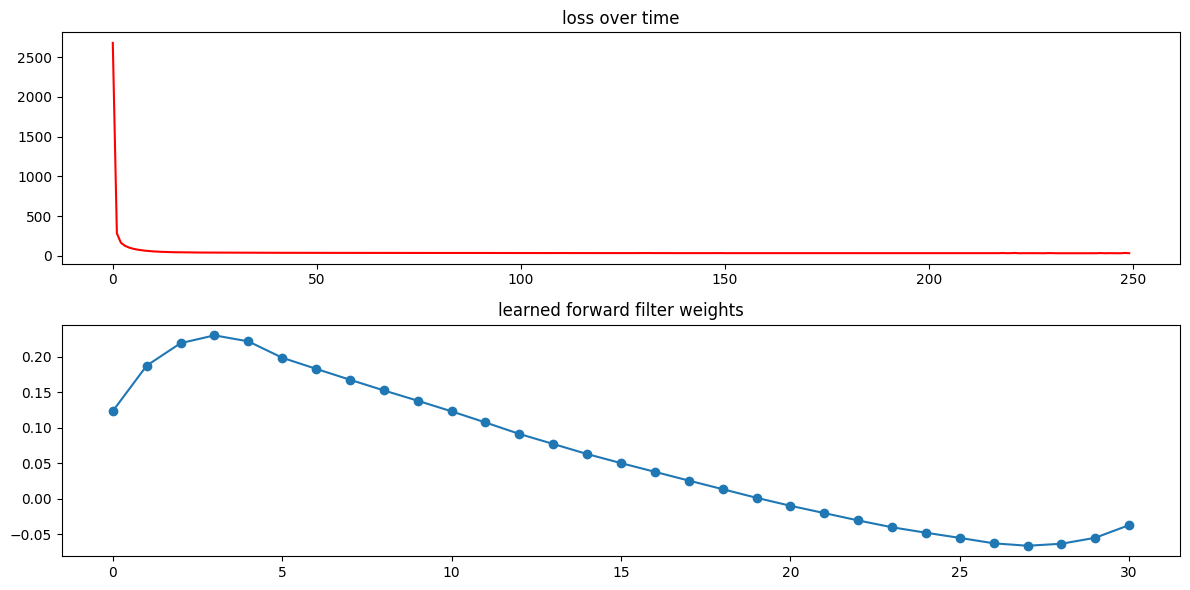

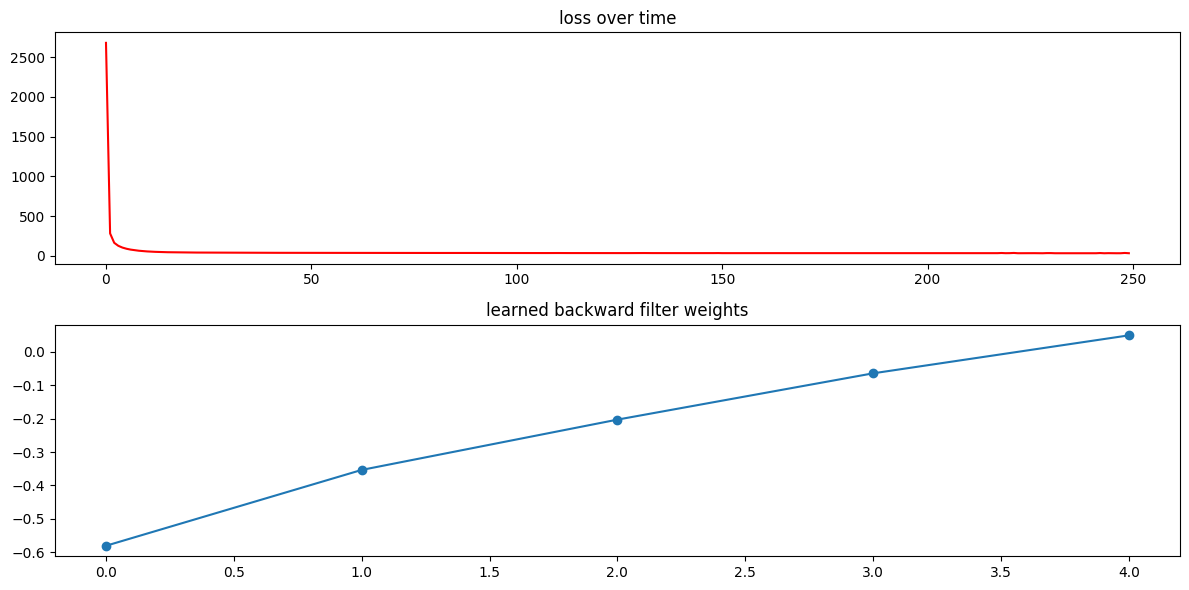

In [4]:
gen_plots(fwd_weights, loss_hist, "learned forward filter weights")
gen_plots(back_weights, loss_hist, "learned backward filter weights")

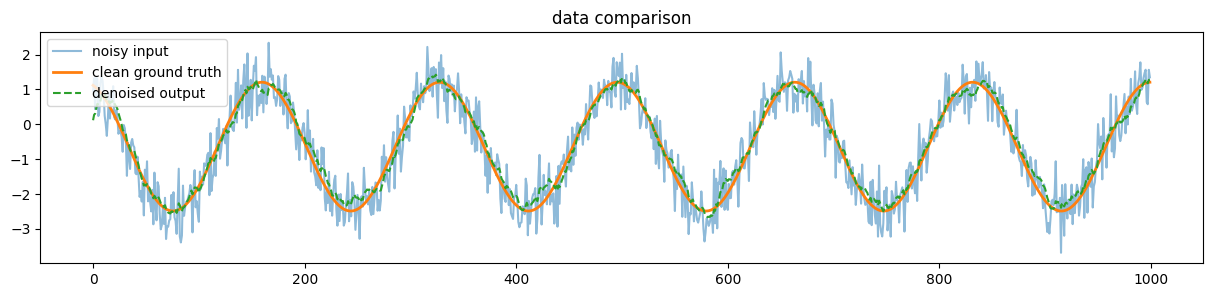

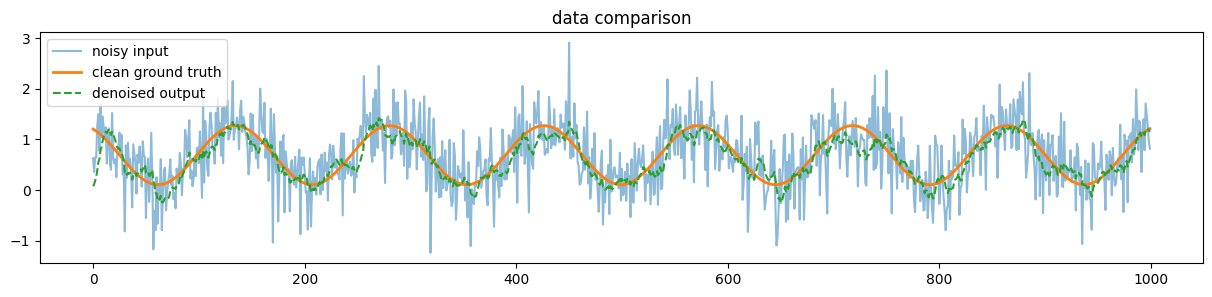

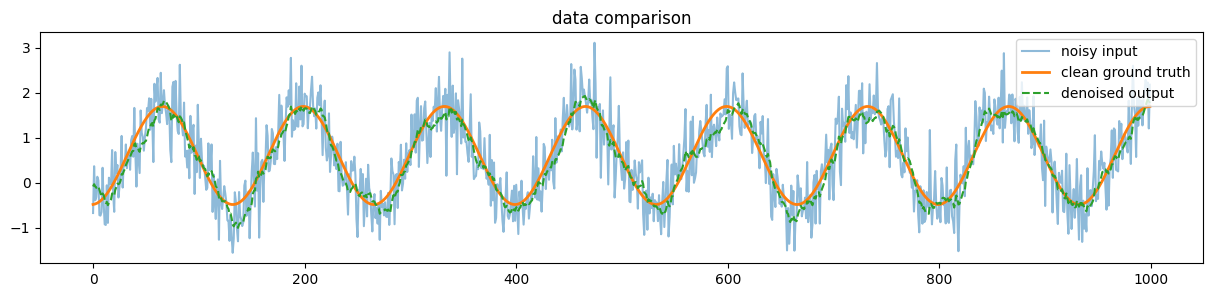

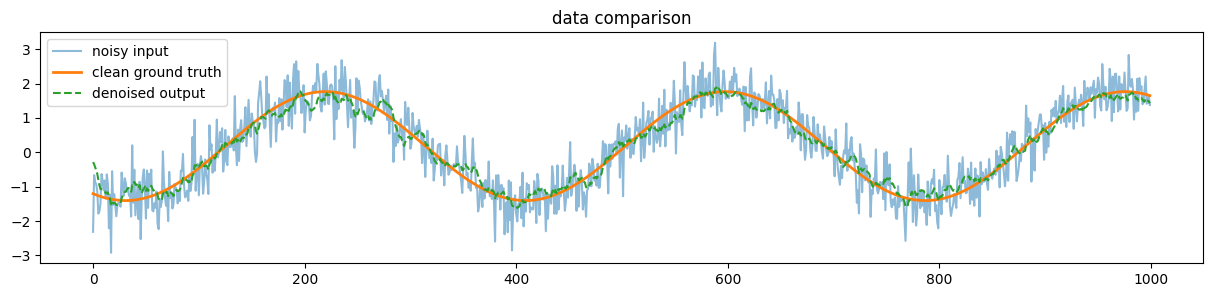

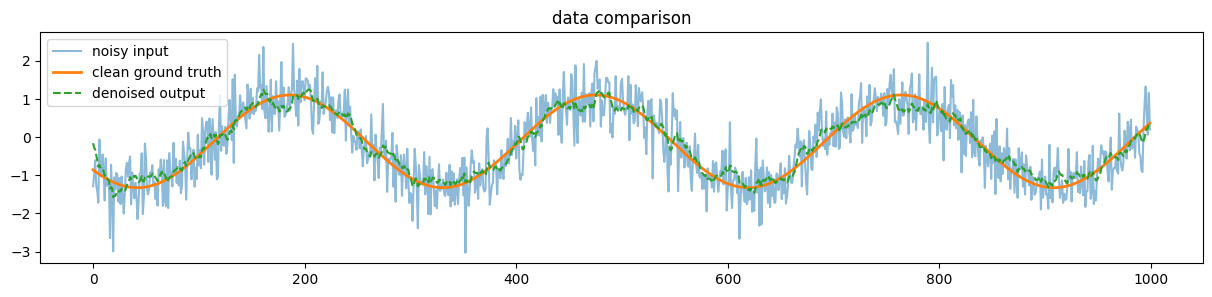

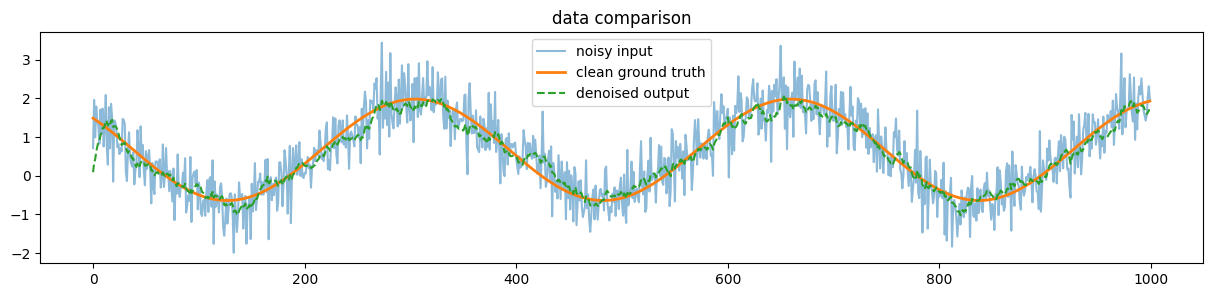

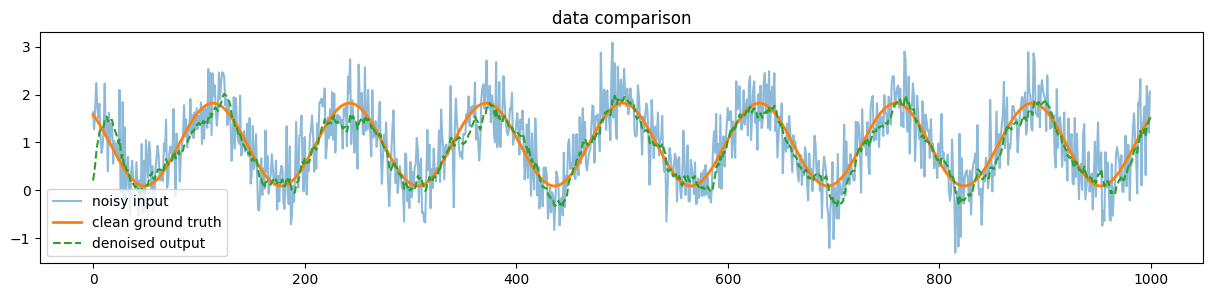

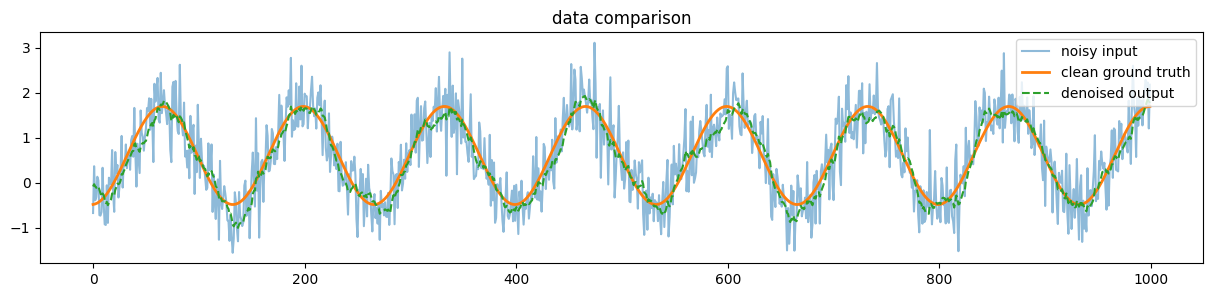

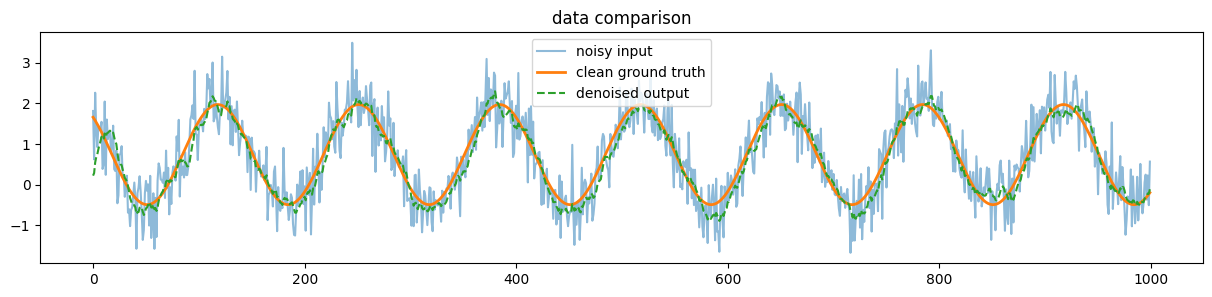

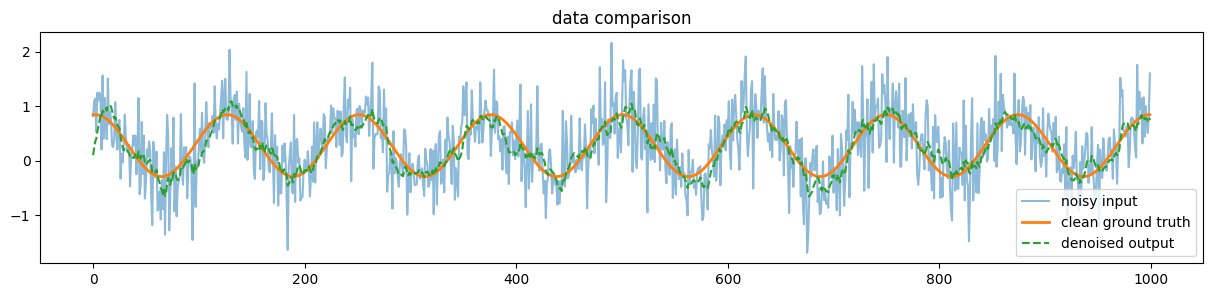

In [5]:
# peak to see on some samples
import matplotlib.pyplot as plt

def peak_sample_perf(noisy_sample, clean_sample, weights):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    b_weights, a_weights = weights
    denoised_audio = np.zeros_like(noisy_sample, dtype=np.float32)
    K = len(b_weights)
    M = len(a_weights)

    for i in range(len(noisy_sample)):
        sum_b = 0.0
        for j in range(min(K, i + 1)):
            sum_b += noisy_sample[i - j] * b_weights[j]

        sum_a = 0.0
        for m in range(min(M, i)):
            sum_a += denoised_audio[i - 1 - m] * a_weights[m]

        denoised_audio[i] = sum_b + sum_a

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

for i in range(10):
    idx = np.random.randint(0, len(noisy_audio))

    noisy_sample = noisy_audio[idx]
    clean_sample = clean_audio[idx]

    peak_sample_perf(noisy_sample, clean_sample, (fwd_weights, back_weights))

## train on audio data

In [2]:
from data_proc.parse_audio_data import parse_audio, save_audio

N = 1000
data = parse_audio("../data/clean/sample1.wav", "../data/noisy/noise1.wav")

fwd_weights, back_weights, loss_hist = train_iir([data[0]], [data[1]], N, K=31, M=5, epochs=2000, BATCH_SIZE=1)


Reverse differentiation of function rev_iir_loss:
def rev_iir_loss(noisy : In[Array[float]], _dnoisy_Nf6bWD : Out[Array[float]], clean : In[Array[float]], _dclean_2sJVio : Out[Array[float]], out_sig : In[Array[float]], _dout_sig_T3LrYL : Out[Array[float]], b_weights : In[Array[float]], _db_weights_M7J7tM : Out[Array[float]], a_weights : In[Array[float]], _da_weights_s8TcTU : Out[Array[float]], N : In[int], _dN_UEnabC : Out[int], K : In[int], _dK_5ErHhc : Out[int], M : In[int], _dM_MrI09K : Out[int], _dreturn_DNP0PJ : In[float]) -> void:
	_t_float_cJ8hLc : Array[float, 530000]
	_stack_ptr_float_cJ8hLc : int = (int)(0)
	_t_int_MCyzxe : Array[int, 510000]
	_stack_ptr_int_MCyzxe : int = (int)(0)
	_loop_var_0_UIaLHV : int
	_loop_var_1_N8Wi53 : int
	_loop_var_1_N8Wi53_stack : Array[int, 10000]
	_loop_var_1_N8Wi53_stack_ptr : int
	_loop_var_2_j1KvVw : int
	_loop_var_2_j1KvVw_stack : Array[int, 10000]
	_loop_var_2_j1KvVw_stack_ptr : int
	loss : float = (float)(0.0)
	_dloss_yIL8pR : float
	i :

training...:  63%|██████▎   | 1268/2000 [00:00<00:00, 6418.24it/s]

Epoch 0 | Loss: 90.0184
Epoch 10 | Loss: 86.6661
Epoch 20 | Loss: 83.4463
Epoch 30 | Loss: 80.3532
Epoch 40 | Loss: 77.3813
Epoch 50 | Loss: 74.5254
Epoch 60 | Loss: 71.7807
Epoch 70 | Loss: 69.1424
Epoch 80 | Loss: 66.6064
Epoch 90 | Loss: 64.1680
Epoch 100 | Loss: 61.8236
Epoch 110 | Loss: 59.5691
Epoch 120 | Loss: 57.4009
Epoch 130 | Loss: 55.3156
Epoch 140 | Loss: 53.3097
Epoch 150 | Loss: 51.3802
Epoch 160 | Loss: 49.5239
Epoch 170 | Loss: 47.7378
Epoch 180 | Loss: 46.0193
Epoch 190 | Loss: 44.3656
Epoch 200 | Loss: 42.7742
Epoch 210 | Loss: 41.2425
Epoch 220 | Loss: 39.7683
Epoch 230 | Loss: 38.3493
Epoch 240 | Loss: 36.9834
Epoch 250 | Loss: 35.6684
Epoch 260 | Loss: 34.4023
Epoch 270 | Loss: 33.1833
Epoch 280 | Loss: 32.0096
Epoch 290 | Loss: 30.8793
Epoch 300 | Loss: 29.7908
Epoch 310 | Loss: 28.7425
Epoch 320 | Loss: 27.7328
Epoch 330 | Loss: 26.7602
Epoch 340 | Loss: 25.8234
Epoch 350 | Loss: 24.9209
Epoch 360 | Loss: 24.0514
Epoch 370 | Loss: 23.2137
Epoch 380 | Loss: 22.40

training...: 100%|██████████| 2000/2000 [00:00<00:00, 5818.64it/s]

Epoch 1270 | Loss: 1.1978
Epoch 1280 | Loss: 1.1615
Epoch 1290 | Loss: 1.1263
Epoch 1300 | Loss: 1.0923
Epoch 1310 | Loss: 1.0593
Epoch 1320 | Loss: 1.0273
Epoch 1330 | Loss: 0.9964
Epoch 1340 | Loss: 0.9664
Epoch 1350 | Loss: 0.9374
Epoch 1360 | Loss: 0.9093
Epoch 1370 | Loss: 0.8820
Epoch 1380 | Loss: 0.8556
Epoch 1390 | Loss: 0.8300
Epoch 1400 | Loss: 0.8052
Epoch 1410 | Loss: 0.7812
Epoch 1420 | Loss: 0.7579
Epoch 1430 | Loss: 0.7354
Epoch 1440 | Loss: 0.7135
Epoch 1450 | Loss: 0.6923
Epoch 1460 | Loss: 0.6718
Epoch 1470 | Loss: 0.6519
Epoch 1480 | Loss: 0.6326
Epoch 1490 | Loss: 0.6139
Epoch 1500 | Loss: 0.5957
Epoch 1510 | Loss: 0.5782
Epoch 1520 | Loss: 0.5611
Epoch 1530 | Loss: 0.5446
Epoch 1540 | Loss: 0.5286
Epoch 1550 | Loss: 0.5131
Epoch 1560 | Loss: 0.4980
Epoch 1570 | Loss: 0.4834
Epoch 1580 | Loss: 0.4693
Epoch 1590 | Loss: 0.4556
Epoch 1600 | Loss: 0.4422
Epoch 1610 | Loss: 0.4293
Epoch 1620 | Loss: 0.4168
Epoch 1630 | Loss: 0.4047
Epoch 1640 | Loss: 0.3929
Epoch 1650 |

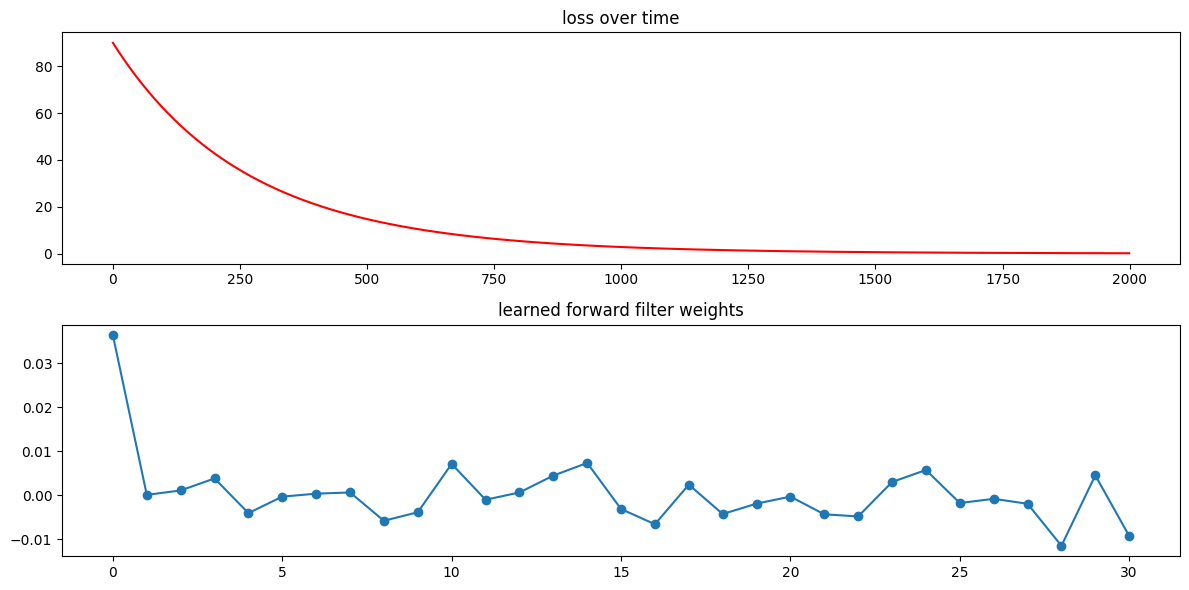

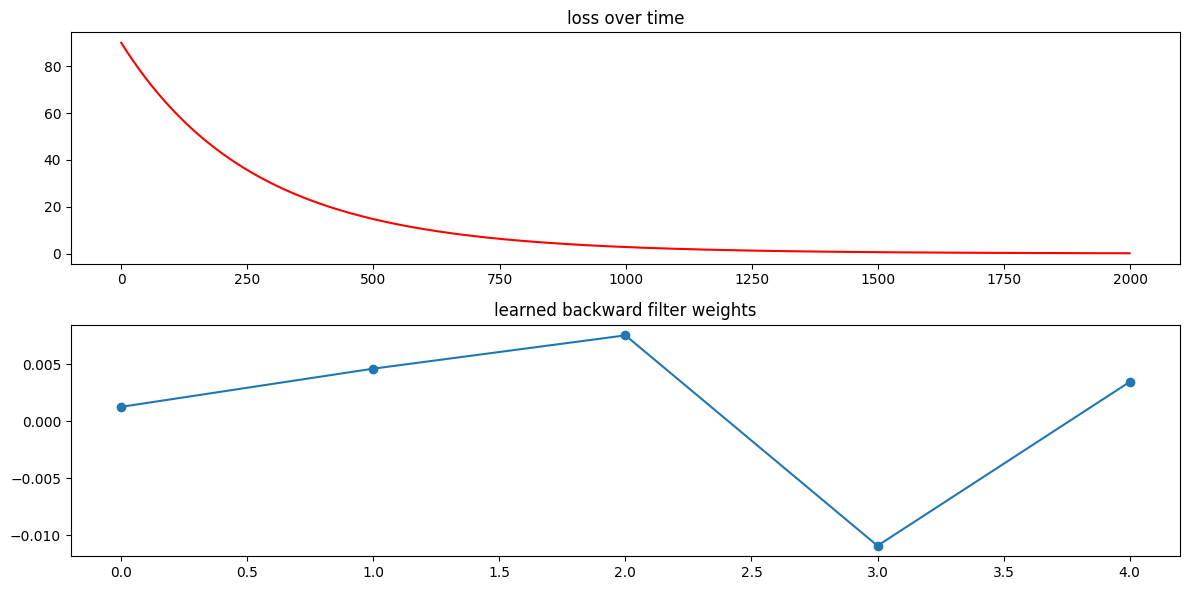

In [3]:
gen_plots(fwd_weights, loss_hist, "learned forward filter weights")
gen_plots(back_weights, loss_hist, "learned backward filter weights")

Successfully saved playable audio to: ../data/generated.wav


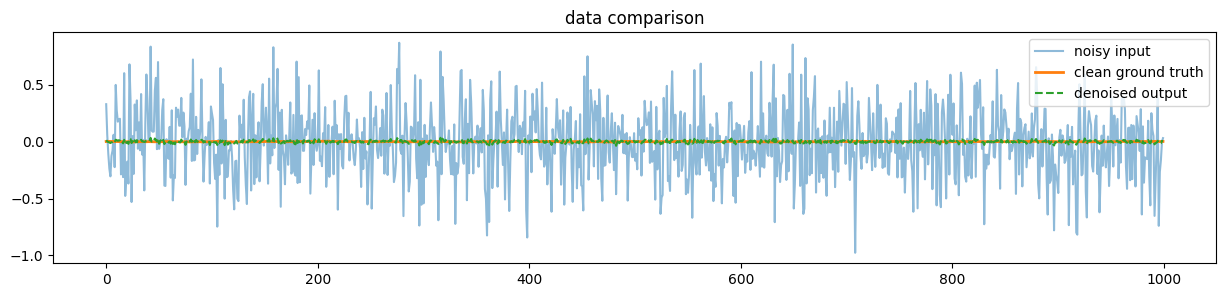

In [5]:
# peak to see on some samples
import matplotlib.pyplot as plt

def peak_sample_perf(noisy_sample, clean_sample, weights):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    b_weights, a_weights = weights
    denoised_audio = np.zeros_like(noisy_sample, dtype=np.float32)
    K = len(b_weights)
    M = len(a_weights)

    for i in range(len(noisy_sample)):
        sum_b = 0.0
        for j in range(min(K, i + 1)):
            sum_b += noisy_sample[i - j] * b_weights[j]

        sum_a = 0.0
        for m in range(min(M, i)):
            sum_a += denoised_audio[i - 1 - m] * a_weights[m]

        denoised_audio[i] = sum_b + sum_a

    save_audio(denoised_audio, 16000, output_path="../data/generated.wav")

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

peak_sample_perf(data[0], data[1], (fwd_weights, back_weights))

In [7]:
save_audio(data[0], 16000, "../data/generated2.wav")

Successfully saved playable audio to: ../data/generated2.wav


In [9]:
data = parse_audio("../data/clean/sample1.wav", "../data/noisy/noise1.wav", None)

save_audio(data[1], 16000, "../data/generated3.wav")

Successfully saved playable audio to: ../data/generated3.wav


Successfully saved playable audio to: ../data/generated.wav


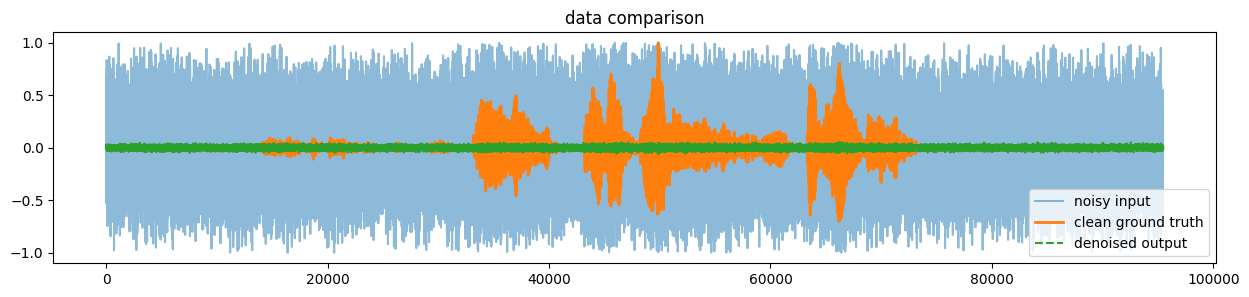

In [10]:
peak_sample_perf(data[0], data[1], (fwd_weights, back_weights))